<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Expression-Quality-Control-(Part-2)" data-toc-modified-id="Expression-Quality-Control-(Part-2)-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Expression Quality Control (Part 2)</a></span><ul class="toc-item"><li><span><a href="#Setup" data-toc-modified-id="Setup-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Setup</a></span><ul class="toc-item"><li><span><a href="#Inputs" data-toc-modified-id="Inputs-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Inputs</a></span></li><li><span><a href="#Load-expression-data" data-toc-modified-id="Load-expression-data-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Load expression data</a></span></li><li><span><a href="#Load-metadata" data-toc-modified-id="Load-metadata-1.1.3"><span class="toc-item-num">1.1.3&nbsp;&nbsp;</span>Load metadata</a></span></li></ul></li><li><span><a href="#Remove-samples-due-to-poor-metadata" data-toc-modified-id="Remove-samples-due-to-poor-metadata-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Remove samples due to poor metadata</a></span><ul class="toc-item"><li><span><a href="#Check-curation" data-toc-modified-id="Check-curation-1.2.1"><span class="toc-item-num">1.2.1&nbsp;&nbsp;</span>Check curation</a></span></li><li><span><a href="#Remove-samples-with-only-one-replicate" data-toc-modified-id="Remove-samples-with-only-one-replicate-1.2.2"><span class="toc-item-num">1.2.2&nbsp;&nbsp;</span>Remove samples with only one replicate</a></span></li><li><span><a href="#Save-this-information-to-the-full-metadata-dataframe" data-toc-modified-id="Save-this-information-to-the-full-metadata-dataframe-1.2.3"><span class="toc-item-num">1.2.3&nbsp;&nbsp;</span>Save this information to the full metadata dataframe</a></span></li></ul></li><li><span><a href="#Check-correlations-between-replicates" data-toc-modified-id="Check-correlations-between-replicates-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Check correlations between replicates</a></span><ul class="toc-item"><li><span><a href="#Remove-failed-data-from-log_tpm-files" data-toc-modified-id="Remove-failed-data-from-log_tpm-files-1.3.1"><span class="toc-item-num">1.3.1&nbsp;&nbsp;</span>Remove failed data from log_tpm files</a></span></li><li><span><a href="#Compute-Pearson-R-Score" data-toc-modified-id="Compute-Pearson-R-Score-1.3.2"><span class="toc-item-num">1.3.2&nbsp;&nbsp;</span>Compute Pearson R Score</a></span></li></ul></li><li><span><a href="#Check-that-reference-conditions-still-exist" data-toc-modified-id="Check-that-reference-conditions-still-exist-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Check that reference conditions still exist</a></span></li><li><span><a href="#Normalize-dataset-to-reference-conditions" data-toc-modified-id="Normalize-dataset-to-reference-conditions-1.5"><span class="toc-item-num">1.5&nbsp;&nbsp;</span>Normalize dataset to reference conditions</a></span></li><li><span><a href="#Save-final-datasets" data-toc-modified-id="Save-final-datasets-1.6"><span class="toc-item-num">1.6&nbsp;&nbsp;</span>Save final datasets</a></span></li></ul></li></ul></div>

# Expression Quality Control (Part 2)

This is a template notebook for performing the final quality control on your organism's expression data. This requires a curated metadata sheet.

## Setup 

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pymodulon.io import load_json_model, save_to_json

from os import path
from scipy import stats
from tqdm.notebook import tqdm

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_style('ticks')
matplotlib.rcParams['text.color'] = '#000000'
matplotlib.rcParams['axes.labelcolor'] = '#000000'
matplotlib.rcParams['xtick.color'] = '#000000'
matplotlib.rcParams['ytick.color'] = '#000000'

In [3]:
sns.set_style('ticks')

In [4]:
ica_data = load_json_model('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\PRECISE_WT_MG1655_final2.json.gz')

### Inputs

In [5]:
logTPM_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\log_tpm_all.csv' # Enter log-TPM filename here
all_metadata_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\metadata_qc_part1_all.csv' # Enter full metadata filename here
metadata_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\metadata_qc_part1_curated.csv' # Enter curated metadata filename here

### Load expression data

In [22]:
DF_log_tpm = pd.read_csv(logTPM_file,index_col=0).fillna(0)
print('Number of genes:',DF_log_tpm.shape[0])
print('Number of samples:',DF_log_tpm.shape[1])
DF_log_tpm.head()

Number of genes: 4305
Number of samples: 653


,p1k_00001,p1k_00002,p1k_00003,p1k_00004,p1k_00005,p1k_00006,p1k_00011,p1k_00012,p1k_00019,p1k_00020,...,pxk_0480,pxk_0481,pxk_0482,pxk_0483,pxk_0484,pxk_0485,pxk_0486,pxk_0487,pxk_0488,pxk_0489
Geneid,,,,,,,,,,,,,,,,,,,,,
b0001,10.473122,10.271701,6.241820,6.612273,9.864203,10.306175,6.942872,7.396447,4.686936,4.969722,...,13.054429,14.430610,15.003129,13.993765,13.156986,13.543981,13.457623,12.783796,14.514099,14.777472
b0002,10.259970,10.368313,11.196750,11.408313,10.496462,10.234807,10.360030,10.371712,7.344004,7.353379,...,10.284493,10.100120,10.975759,10.958763,10.903817,10.906640,10.094332,10.380296,9.837189,9.785318
b0003,9.919679,10.043981,11.048725,11.464290,10.374269,10.216039,10.362168,10.420442,7.838860,7.874283,...,10.153224,9.897669,10.528434,10.608389,10.551635,10.575377,9.821258,10.091336,9.578890,9.492098
b0004,9.936095,10.010396,9.979940,10.334517,9.876356,9.637871,9.749910,9.682739,7.045102,7.160390,...,10.167923,9.917367,10.216795,10.330276,10.358766,10.280178,9.814895,10.053651,9.494064,9.457453
b0005,7.026920,7.237208,6.017434,5.858599,6.950386,6.767550,6.097440,6.224967,4.550292,4.288234,...,6.554896,6.512602,5.808328,6.202771,6.308244,6.129644,6.204521,6.385413,5.929225,5.605208


### Load metadata

In [23]:
DF_metadata = pd.read_csv(metadata_file,index_col=0)
print('Number of samples with curated metadata:',DF_metadata.shape[0])
DF_metadata.head()

Number of samples with curated metadata: 642


,sample_id,study,project,reference_condition,condition,rep_id,Strain Description,Strain,Culture Type,Evolved Sample,...,passed_global_correlation,full_name,passed_similar_replicates,passed_number_replicates,run_date,n_replicates,PxK_sample_type,deleted_genes,mutated_genes,overexpressed_genes
p1k_00001,control__wt_glc__1,Control,control,wt_glc,wt_glc,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,control:wt_glc,True,True,4/17/2013,2.0,WT,NaN,NaN,NaN
p1k_00002,control__wt_glc__2,Control,control,wt_glc,wt_glc,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,control:wt_glc,True,True,4/17/2013,2.0,WT,NaN,NaN,NaN
p1k_00003,fur__wt_dpd__1,Fur,fur,wt_fe,wt_dpd,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_dpd,True,True,10/2/2013,2.0,WT,NaN,NaN,NaN
p1k_00004,fur__wt_dpd__2,Fur,fur,wt_fe,wt_dpd,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_dpd,True,True,10/2/2013,2.0,WT,NaN,NaN,NaN
p1k_00005,fur__wt_fe__1,Fur,fur,wt_fe,wt_fe,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_fe,True,True,9/5/2013,2.0,WT,NaN,NaN,NaN


In [24]:
DF_metadata_all = pd.read_csv(all_metadata_file,index_col=0)

## Remove samples due to poor metadata

After curation, some samples either did not have enough replicates or metadata to warrant inclusion in this database. Add a `skip` column to the metadata to exclude these samples.

In [25]:
# DF_metadata_passed_step4 = DF_metadata[~DF_metadata.skip.fillna(False)].copy()
DF_metadata_passed_step4 = DF_metadata.copy()
print('New number of samples with curated metadata:',DF_metadata_passed_step4.shape[0])
DF_metadata_passed_step4.head()

New number of samples with curated metadata: 642


,sample_id,study,project,reference_condition,condition,rep_id,Strain Description,Strain,Culture Type,Evolved Sample,...,passed_global_correlation,full_name,passed_similar_replicates,passed_number_replicates,run_date,n_replicates,PxK_sample_type,deleted_genes,mutated_genes,overexpressed_genes
p1k_00001,control__wt_glc__1,Control,control,wt_glc,wt_glc,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,control:wt_glc,True,True,4/17/2013,2.0,WT,NaN,NaN,NaN
p1k_00002,control__wt_glc__2,Control,control,wt_glc,wt_glc,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,control:wt_glc,True,True,4/17/2013,2.0,WT,NaN,NaN,NaN
p1k_00003,fur__wt_dpd__1,Fur,fur,wt_fe,wt_dpd,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_dpd,True,True,10/2/2013,2.0,WT,NaN,NaN,NaN
p1k_00004,fur__wt_dpd__2,Fur,fur,wt_fe,wt_dpd,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_dpd,True,True,10/2/2013,2.0,WT,NaN,NaN,NaN
p1k_00005,fur__wt_fe__1,Fur,fur,wt_fe,wt_fe,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_fe,True,True,9/5/2013,2.0,WT,NaN,NaN,NaN


### Check curation
Since manual curation is error-prone, we want to make sure that all samples have labels for their project and condition. In addition, there should only be one reference condition in each project, and it should be in the project itself.

Any samples that fail these checks will be printed below.

In [26]:
assert(DF_metadata_passed_step4.project.notnull().all())
assert(DF_metadata_passed_step4.condition.notnull().all())

for name,group in DF_metadata_passed_step4.groupby('project'):
    ref_cond = group.reference_condition.unique()
    
    # Ensure that there is only one reference condition per project
    if not len(ref_cond) == 1:
        print('Multiple reference conditions for:', name)
    
    # Ensure the reference condition is in fact in the project
    ref_cond = ref_cond[0]
    if not ref_cond in group.condition.tolist():
        print('Reference condition not in project:', name)

Next, make a new column called ``full_name`` that gives every experimental condition a unique, human-readable identifier.

In [27]:
DF_metadata_passed_step4['full_name'] = DF_metadata_passed_step4['project'].str.cat(DF_metadata_passed_step4['condition'],sep=':')

### Remove samples with only one replicate

First, find sample names that have at least two replicates.

In [28]:
counts = DF_metadata_passed_step4.full_name.value_counts()
keep_samples = counts[counts >= 2].index
print(keep_samples[:5])

Index(['ica:wt_glc', 'electric_coli:biodesign_dmso',
       'electric_coli:biodesign_hnq', 'ytf5:wt_glc_24hr',
       'electric_coli:ebk_hnq10_biod'],
      dtype='object')


In [29]:
# checking samples with only one replicate
low_rep_samples = counts[counts == 1].index
low_rep_samples

Index(['antibiotICA:amp_1_4_t3_5', 'ytf4:wt_pH7_pyruvate', 'misc:nitr_031',
       'ssw:wt_glyc', 'ssw:wt_glc', 'minspan:wt_trp', 'rpoB:wt_031',
       'rpoB:wt_044', 'crp:wt_fru', 'ssw:wt_xyl', '42c:wt_42c', 'ssw:wt_ac',
       'minspan:wt_ade'],
      dtype='object')

Only keep these samples

In [30]:
DF_metadata_passed_step4 = DF_metadata_passed_step4[DF_metadata_passed_step4.full_name.isin(keep_samples)]
print('New number of samples with curated metadata:',DF_metadata_passed_step4.shape[0])
DF_metadata_passed_step4.head()

New number of samples with curated metadata: 629


,sample_id,study,project,reference_condition,condition,rep_id,Strain Description,Strain,Culture Type,Evolved Sample,...,passed_global_correlation,full_name,passed_similar_replicates,passed_number_replicates,run_date,n_replicates,PxK_sample_type,deleted_genes,mutated_genes,overexpressed_genes
p1k_00001,control__wt_glc__1,Control,control,wt_glc,wt_glc,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,control:wt_glc,True,True,4/17/2013,2.0,WT,NaN,NaN,NaN
p1k_00002,control__wt_glc__2,Control,control,wt_glc,wt_glc,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,control:wt_glc,True,True,4/17/2013,2.0,WT,NaN,NaN,NaN
p1k_00003,fur__wt_dpd__1,Fur,fur,wt_fe,wt_dpd,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_dpd,True,True,10/2/2013,2.0,WT,NaN,NaN,NaN
p1k_00004,fur__wt_dpd__2,Fur,fur,wt_fe,wt_dpd,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_dpd,True,True,10/2/2013,2.0,WT,NaN,NaN,NaN
p1k_00005,fur__wt_fe__1,Fur,fur,wt_fe,wt_fe,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,True,fur:wt_fe,True,True,9/5/2013,2.0,WT,NaN,NaN,NaN


### Save this information to the full metadata dataframe

In [31]:
DF_metadata_all['passed_curation'] = DF_metadata_all.index.isin(DF_metadata_passed_step4.index)

## Check correlations between replicates

### Remove failed data from log_tpm files

In [32]:
DF_log_tpm = DF_log_tpm[DF_metadata_passed_step4.index]

In [33]:
counts

ica:wt_glc                      6
electric_coli:biodesign_dmso    3
electric_coli:biodesign_hnq     3
ytf5:wt_glc_24hr                3
electric_coli:ebk_hnq10_biod    3
                               ..
crp:wt_fru                      1
ssw:wt_xyl                      1
42c:wt_42c                      1
ssw:wt_ac                       1
minspan:wt_ade                  1
Name: full_name, Length: 323, dtype: int64

In [34]:
DF_counts = DF_counts[DF_metadata_passed_step4.index]

### Compute Pearson R Score

Biological replicates should have a Pearson R correlation above 0.95. For samples with more than 2 replicates, the replicates must have R >= 0.95 with at least one other replicate or it will be dropped. The correlation threshold can be changed below:

In [38]:
rcutoff = 0.95

The following code computes correlations between all samples and collects correlations between replicates and non-replicates.

In [39]:
rep_corrs = {}
rand_corrs = {}

num_comparisons = len(DF_metadata_passed_step4)*(len(DF_metadata_passed_step4)-1)/2

for exp1,exp2 in tqdm(itertools.combinations(DF_metadata_passed_step4.index,2),total=num_comparisons):
    if DF_metadata_passed_step4.loc[exp1,'full_name'] == DF_metadata_passed_step4.loc[exp2,'full_name']:
        rep_corrs[(exp1,exp2)] = stats.pearsonr(DF_log_tpm[exp1],DF_log_tpm[exp2])[0]
    else:
        rand_corrs[(exp1,exp2)] = stats.pearsonr(DF_log_tpm[exp1],DF_log_tpm[exp2])[0]

  0%|          | 0/197506.0 [00:00<?, ?it/s]

Correlations can be plotted on a histogram

Median Pearson R between replicates: 0.99


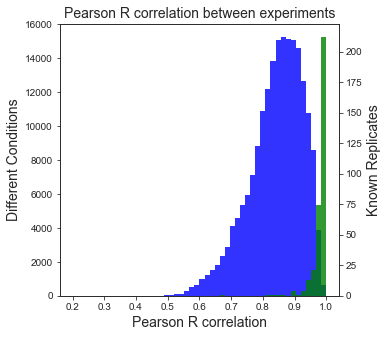

In [40]:
fig,ax = plt.subplots(figsize=(5,5))
ax2 = ax.twinx()
ax2.hist(rep_corrs.values(),bins=50,range=(0.2,1),alpha=0.8,color='green',linewidth=0)
ax.hist(rand_corrs.values(),bins=50,range=(0.2,1),alpha=0.8,color='blue',linewidth=0)
ax.set_title('Pearson R correlation between experiments',fontsize=14)
ax.set_xlabel('Pearson R correlation',fontsize=14)
ax.set_ylabel('Different Conditions',fontsize=14)
ax2.set_ylabel('Known Replicates',fontsize=14)

med_corr = np.median([v for k,v in rep_corrs.items()])
print('Median Pearson R between replicates: {:.2f}'.format(med_corr))

In [41]:
med_rand_corr = np.median([v for k,v in rand_corrs.items()])
print('Median Pearson R between non-replicates: {:.2f}'.format(med_rand_corr))

Median Pearson R between non-replicates: 0.85


Remove samples without any high-correlation replicates

In [42]:
dissimilar = []
for idx, grp in DF_metadata_passed_step4.groupby('full_name'):
    ident = np.identity(len(grp))
    corrs = (DF_log_tpm[grp.index].corr() - ident).max()
    dissimilar.extend(corrs[corrs<rcutoff].index)

# Save this information in both the original metadata dataframe and the new metadata dataframe
DF_metadata_all['passed_replicate_correlations'] = ~DF_metadata_all.index.isin(dissimilar)
DF_metadata_passed_step4['passed_replicate_correlations'] = ~DF_metadata_passed_step4.index.isin(dissimilar)

In [43]:
DF_metadata_passed_step4.loc[dissimilar]

,sample_id,study,project,reference_condition,condition,rep_id,Strain Description,Strain,Culture Type,Evolved Sample,...,full_name,passed_similar_replicates,passed_number_replicates,run_date,n_replicates,PxK_sample_type,deleted_genes,mutated_genes,overexpressed_genes,passed_replicate_correlations
pxk_0252,N_Guanosine_1,single_nutrient_perturbation,SNPv1,D-Glucose_NH4Cl,Glucose_Guanosine,1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv1:Glucose_Guanosine,NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0253,N_Guanosine_2,single_nutrient_perturbation,SNPv1,D-Glucose_NH4Cl,Glucose_Guanosine,2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv1:Glucose_Guanosine,NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0400,Supp_Adenosine_(10mM)_1,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_Adenosine_(10mM),1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_Adenosine_(10mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0401,Supp_Adenosine_(10mM)_2,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_Adenosine_(10mM),2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_Adenosine_(10mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0344,Supp_Aspartic acid_(10mM)_1,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_Aspartic acid_(10mM),1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_Aspartic acid_(10mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0345,Supp_Aspartic acid_(10mM)_2,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_Aspartic acid_(10mM),2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_Aspartic acid_(10mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0430,Supp_D-Ribose_(2mM)_1,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_D-Ribose_(2mM),1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_D-Ribose_(2mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0431,Supp_D-Ribose_(2mM)_2,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_D-Ribose_(2mM),2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_D-Ribose_(2mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0356,Supp_Isoleucine_(10mM)_1,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_Isoleucine_(10mM),1,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_Isoleucine_(10mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False
pxk_0357,Supp_Isoleucine_(10mM)_2,single_nutrient_perturbation,SNPv2,Glucose_NH4Cl,Supp_Isoleucine_(10mM),2,Escherichia coli K-12 MG1655,MG1655,Batch,No,...,SNPv2:Supp_Isoleucine_(10mM),NaN,NaN,7/19/2024,NaN,WT,NaN,NaN,NaN,False


In [44]:
DF_metadata_final = DF_metadata_passed_step4[DF_metadata_passed_step4['passed_replicate_correlations']]
print('# Samples that passed replicate correlations:',len(DF_metadata_final))

# Samples that passed replicate correlations: 586


## Check that reference conditions still exist
If a reference condition was removed due to poor replicate correlations, a new reference condition needs to be defined.

Again, any samples that fail these checks will be printed below.

In [45]:
project_exprs = []
single_cond_projects = []

for name,group in DF_metadata_final.groupby('project'):
    
    # Get reference condition
    ref_cond = group.reference_condition.iloc[0]
    
    # Ensure the reference condition is still in the project
    if ref_cond not in group.condition.tolist():
        print('Reference condition missing from:', name)
    
    # Check that each project has at least two conditions (a reference and at least one test condition)
    ########### these samples will be kept, but will be normalized to the global reference
    if len(group.condition.unique()) <= 1:
        print('Only one condition in:', name)
        single_cond_projects.append(name)

Only one condition in: CFP
Only one condition in: acid
Only one condition in: adnB
Only one condition in: control
Only one condition in: crp
Only one condition in: eep
Only one condition in: misc
Only one condition in: ompr
Only one condition in: oxidative
Only one condition in: plasmid
Only one condition in: rpoB
Only one condition in: ytf2


In [46]:
single_cond_projects

['CFP',
 'acid',
 'adnB',
 'control',
 'crp',
 'eep',
 'misc',
 'ompr',
 'oxidative',
 'plasmid',
 'rpoB',
 'ytf2']

In [47]:
# projects that need to be normalized to global reference
global_ref_projects = single_cond_projects.copy()
global_ref_projects.append('misc2')
global_ref_projects

['CFP',
 'acid',
 'adnB',
 'control',
 'crp',
 'eep',
 'misc',
 'ompr',
 'oxidative',
 'plasmid',
 'rpoB',
 'ytf2',
 'misc2']

If necessary, choose a new condition for failed projects and re-run notebook.

## Normalize dataset to reference conditions

In [48]:
DF_log_tpm_final = DF_log_tpm[DF_metadata_final.index]

In [49]:
project_ref_projects = list(set(list(np.unique(DF_metadata_final.project.values))).difference(set(global_ref_projects)))

In [50]:
#### modified based on need for project/global reference
#### single condition projects will not contribute to ICA as they will be normalized to themselves -- I will be normalizing
#### them to the global reference instead, which will allow they to contribute in some way. misc projects as well.

project_exprs = []
for name,group in DF_metadata_final.groupby('project'):
    if name in project_ref_projects:
#         print('project_ref', name)
        # Get reference condition (project ref)
        ref_cond = group.reference_condition.iloc[0]

        # Get reference condition sample ids
        ref_samples = group[group.condition == ref_cond].index

        # Get reference condition expression
        ref_expr = DF_log_tpm_final[ref_samples].mean(axis=1)

        # Subtract reference expression from project
        project_exprs.append(DF_log_tpm_final[group.index].sub(ref_expr,axis=0))
    else:
#         print('global_ref', name)
        # Get reference condition (global ref) -- already know sample ids (p1k_00001, p1k_00002)
#         ref_cond = group.reference_condition.iloc[0]

        # Get reference condition sample ids
#         ref_samples = group[group.condition == ref_cond].index

        # Get reference condition expression
        ref_expr = DF_log_tpm_final[['p1k_00001', 'p1k_00002']].mean(axis=1)

        # Subtract reference expression from project
        project_exprs.append(DF_log_tpm_final[group.index].sub(ref_expr,axis=0))

DF_log_tpm_norm = pd.concat(project_exprs,axis=1)

## Save final datasets

In [51]:
# logTPM_qc_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\log_tpm.csv'
# logTPM_norm_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\log_tpm_norm.csv'
# final_metadata_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\metadata.csv'
# final_metadata_all_file = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\QC\\metadata_qc_part2_all.csv'

# DF_log_tpm_final.to_csv(logTPM_qc_file)
# DF_log_tpm_norm.to_csv(logTPM_norm_file)
# DF_metadata_final.to_csv(final_metadata_file)
# DF_metadata_all.to_csv(final_metadata_all_file)

In [52]:
# unique conditions for ICA dimensionality 

project_exprs = []
count = 0

for name,group in DF_metadata_final.groupby('project'):
    count += len(np.unique(group.condition.values))

count

289

In [53]:
# number of projects
len(np.unique(DF_metadata_final.project))

33